# Da Terra ao Código — Classificação de Grãos de Trigo com Machine Learning

**FIAP · FASE 4 · CAP 3 — Atividade "Ir Além"**

Automatização da classificação de variedades de grãos de trigo (**Kama**, **Rosa**
e **Canadian**) a partir de suas características físicas, aplicando a metodologia
**CRISP-DM** (Cross-Industry Standard Process for Data Mining).

> Em cooperativas agrícolas de pequeno porte a classificação dos grãos costuma ser
> feita manualmente por especialistas — um processo lento e sujeito a erro humano.
> Este notebook mostra como um modelo de aprendizado de máquina pode automatizar
> essa tarefa com alta acurácia.

### 👨‍🎓 Integrantes
- Luis Felipe Bardi — RM569479
- Karina Queiroz de Gennaro — RM570928
- Beatriz de Oliveira Ossola Ribeiro — RM570190

### 🗺️ Roteiro (CRISP-DM)
1. **Entendimento do Negócio** — o problema da cooperativa.
2. **Entendimento dos Dados** — estatísticas, distribuições e correlações.
3. **Preparação dos Dados** — valores ausentes, escalonamento e split treino/teste.
4. **Modelagem** — 5 algoritmos de classificação + validação cruzada.
5. **Avaliação** — acurácia, precisão, recall, F1 e matrizes de confusão.
6. **Otimização** — *Grid Search* de hiperparâmetros e re-avaliação.
7. **Interpretação e Conclusões** — insights e recomendações para a cooperativa.

> **Convenção:** todo o **código e os identificadores estão em inglês**; toda a
> **documentação e as figuras estão em português** (público-alvo brasileiro).

## 1. Entendimento do Negócio (Business Understanding)

**Objetivo de negócio:** substituir a triagem manual de grãos por um classificador
automático, **reduzindo tempo e erro** na separação das três variedades de trigo.

**Objetivo de mineração de dados:** treinar um modelo de **classificação
supervisionada** que, dadas as 7 medidas físicas de um grão, preveja sua variedade
(Kama / Rosa / Canadian).

**Critério de sucesso:** acurácia e F1-macro elevados e **estáveis** (verificados
por validação cruzada, não apenas em uma única partição de teste), com erros
distribuídos de forma compreensível à luz da agronomia.

**Dados:** *Seeds Dataset* (UCI Machine Learning Repository) — 210 amostras
(70 por variedade) com 7 atributos contínuos derivados de imagens de raios-X dos grãos.

### Configuração do ambiente

A célula abaixo torna o pacote `src/` importável (independentemente de o kernel
iniciar na raiz do projeto ou em `src/`) e importa a configuração central
(`config.py`) e a camada de dados (`data.py`).

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make src/ importable whether the kernel starts at the project root or in src/.
_cwd = Path.cwd()
_src = _cwd / "src" if (_cwd / "src" / "config.py").exists() else _cwd
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import config
from config import (
    FEATURES, TARGET, TARGET_NAME, CLASS_MAP, FEATURE_LABELS_PT, PALETTE,
    SEED, TEST_SIZE, CV_FOLDS, SCORING, FIGURES_DIR, MODELS_DIR,
    METRICS_BASELINE_PATH, METRICS_TUNED_PATH, BEST_PARAMS_PATH, build_models,
)
from data import load_seeds

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, learning_curve,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib
import sklearn

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(SEED)

print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)
print("Random seed:", SEED, "| test size:", TEST_SIZE, "| CV folds:", CV_FOLDS)

pandas 3.0.3 | numpy 2.4.6 | scikit-learn 1.9.0
Random seed: 42 | test size: 0.3 | CV folds: 5


In [2]:
# ── Small helpers reused across the notebook ────────────────────────────────
CLASS_LABELS = list(CLASS_MAP)                      # [1, 2, 3]
CLASS_NAMES = [CLASS_MAP[i] for i in CLASS_LABELS]  # ['Kama', 'Rosa', 'Canadian']
NAME_PALETTE = {CLASS_MAP[i]: PALETTE[i] for i in CLASS_MAP}  # variety name -> color
FEATURE_LABELS = [FEATURE_LABELS_PT[f] for f in FEATURES]      # PT labels, in FEATURES order


def save_fig(filename: str) -> None:
    # Persist the current figure under docs/figures/ (visual documentation).
    plt.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")


def compute_metrics(y_true, y_pred) -> dict:
    # Accuracy + macro-averaged precision/recall/F1 (fair for balanced classes).
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1": f1_score(y_true, y_pred, average="macro"),
    }

## 2. Entendimento dos Dados (Data Understanding)

### 2.1 Importação e primeiras linhas

O carregamento e a limpeza ficam isolados em `src/data.py`. O arquivo original do
UCI é separado por espaços em branco irregulares (algumas linhas têm tabulações
duplas), por isso usamos o separador `\s+`. A coluna inteira `variety` (1/2/3) é
mapeada para o nome legível da variedade.

| # | Atributo (código) | Atributo (pt) | Descrição |
|---|---|---|---|
| 1 | `area` | Área | Área *A* do grão |
| 2 | `perimeter` | Perímetro | Perímetro *P* do contorno |
| 3 | `compactness` | Compacidade | *C = 4·π·A / P²* |
| 4 | `kernel_length` | Comprimento do núcleo | Eixo principal da elipse equivalente |
| 5 | `kernel_width` | Largura do núcleo | Eixo secundário da elipse |
| 6 | `asymmetry` | Coef. de assimetria | Assimetria do grão |
| 7 | `groove_length` | Comprimento do sulco | Comprimento do sulco central |
| — | `variety` | Variedade | Classe: 1=Kama, 2=Rosa, 3=Canadian |

In [3]:
df = load_seeds()
print("Dimensões:", df.shape)
df.head()

Dimensões: (210, 9)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,variety,variety_name
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


In [4]:
# Column dtypes — confirm all 7 features are numeric and the target is integer.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area           210 non-null    float64 
 1   perimeter      210 non-null    float64 
 2   compactness    210 non-null    float64 
 3   kernel_length  210 non-null    float64 
 4   kernel_width   210 non-null    float64 
 5   asymmetry      210 non-null    float64 
 6   groove_length  210 non-null    float64 
 7   variety        210 non-null    int64   
 8   variety_name   210 non-null    category
dtypes: category(1), float64(7), int64(1)
memory usage: 13.6 KB


### 2.2 Estatísticas descritivas (média, mediana, desvio padrão)

In [5]:
desc = df[FEATURES].agg(["mean", "median", "std", "min", "max"]).T
desc.columns = ["Média", "Mediana", "Desvio padrão", "Mínimo", "Máximo"]
desc.index = FEATURE_LABELS
desc.round(3)

,Média,Mediana,Desvio padrão,Mínimo,Máximo
Área,14.848,14.355,2.910,10.590,21.180
Perímetro,14.559,14.320,1.306,12.410,17.250
Compacidade,0.871,0.873,0.024,0.808,0.918
Comprimento do núcleo,5.629,5.524,0.443,4.899,6.675
Largura do núcleo,3.259,3.237,0.378,2.630,4.033
Coef. de assimetria,3.700,3.599,1.504,0.765,8.456
Comprimento do sulco,5.408,5.223,0.491,4.519,6.550


A média por variedade já antecipa a separabilidade do problema: **Rosa** é a maior
em quase todas as dimensões, **Canadian** a menor, e **Kama** ocupa uma posição
intermediária (o que, como veremos, a torna a classe mais difícil).

In [6]:
df.groupby(TARGET_NAME, observed=True)[FEATURES].mean().round(2)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
variety_name,,,,,,,
Kama,14.33,14.29,0.88,5.51,3.24,2.67,5.09
Rosa,18.33,16.14,0.88,6.15,3.68,3.64,6.02
Canadian,11.87,13.25,0.85,5.23,2.85,4.79,5.12


### 2.3 Valores ausentes e balanceamento das classes

Duas verificações essenciais antes de modelar: (a) existem dados faltantes? e
(b) as classes estão balanceadas (o que define a métrica adequada)?

Total de valores ausentes: 0

Distribuição das classes:
variety_name
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


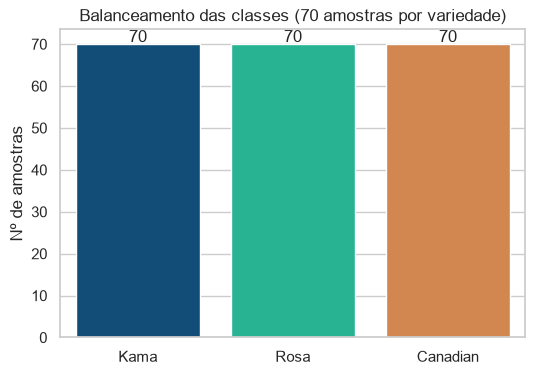

In [7]:
missing = df.isna().sum()
print("Total de valores ausentes:", int(missing.sum()))
print("\nDistribuição das classes:")
counts = df[TARGET_NAME].value_counts().reindex(CLASS_NAMES)
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=NAME_PALETTE, legend=False, ax=ax)
ax.set_title("Balanceamento das classes (70 amostras por variedade)")
ax.set_xlabel(""); ax.set_ylabel("Nº de amostras")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
save_fig("class_balance.png"); plt.show()

**Não há valores ausentes** e o dataset é **perfeitamente balanceado** (70/70/70).
Consequências práticas:
- nenhuma imputação é necessária;
- a **acurácia** é uma métrica confiável aqui, mas reportamos também **precisão,
  recall e F1 (média macro)** — a média *macro* dá o mesmo peso às três classes,
  alinhada ao interesse da cooperativa em acertar **todas** as variedades.

### 2.4 Distribuição das características — histogramas

Sobrepor as distribuições por variedade revela quais atributos separam bem as
classes (curvas distantes) e quais se sobrepõem (curvas misturadas).

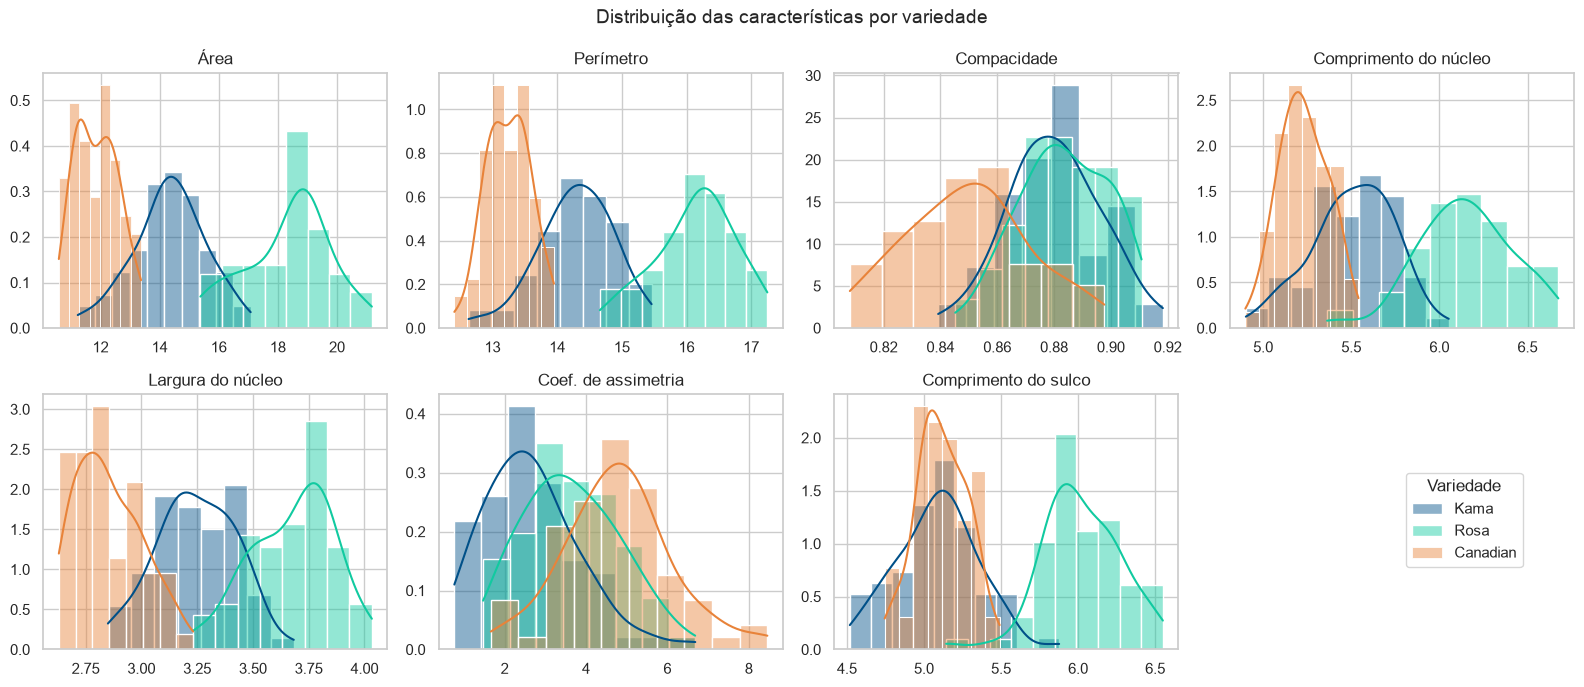

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), FEATURES):
    for cls, name in CLASS_MAP.items():
        sns.histplot(df.loc[df[TARGET] == cls, col], ax=ax, label=name,
                     color=PALETTE[cls], alpha=0.45, kde=True, stat="density",
                     edgecolor=None)
    ax.set_title(FEATURE_LABELS_PT[col]); ax.set_xlabel(""); ax.set_ylabel("")
axes.ravel()[-1].axis("off")  # 7 features in a 2x4 grid -> last cell stays empty
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Variedade", loc="center", bbox_to_anchor=(0.92, 0.25))
fig.suptitle("Distribuição das características por variedade", fontsize=14)
fig.tight_layout(); save_fig("histograms.png"); plt.show()

### 2.5 Distribuição das características — boxplots

Os boxplots por variedade tornam explícita a separação de medianas e a presença de
*outliers*. Atributos como **área**, **perímetro** e **comprimento do sulco**
separam nitidamente as três classes; o **coeficiente de assimetria** é o que mais
se sobrepõe.

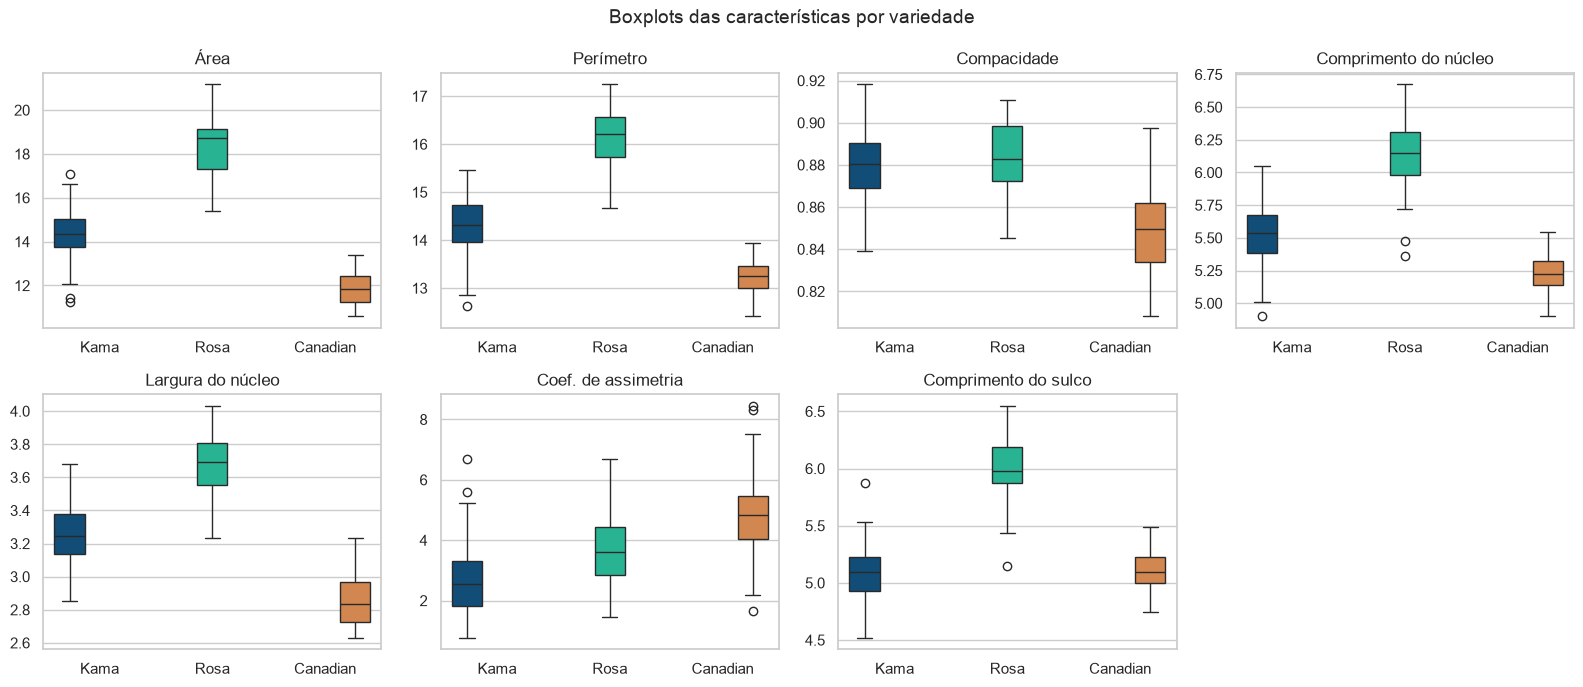

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET_NAME, y=col, hue=TARGET_NAME,
                palette=NAME_PALETTE, legend=False, ax=ax)
    ax.set_title(FEATURE_LABELS_PT[col]); ax.set_xlabel(""); ax.set_ylabel("")
axes.ravel()[-1].axis("off")
fig.suptitle("Boxplots das características por variedade", fontsize=14)
fig.tight_layout(); save_fig("boxplots.png"); plt.show()

### 2.6 Relações entre características — correlação

Como os atributos são medidas geométricas do mesmo grão, espera-se forte
correlação entre os de "tamanho" (área, perímetro, comprimento e largura do núcleo).

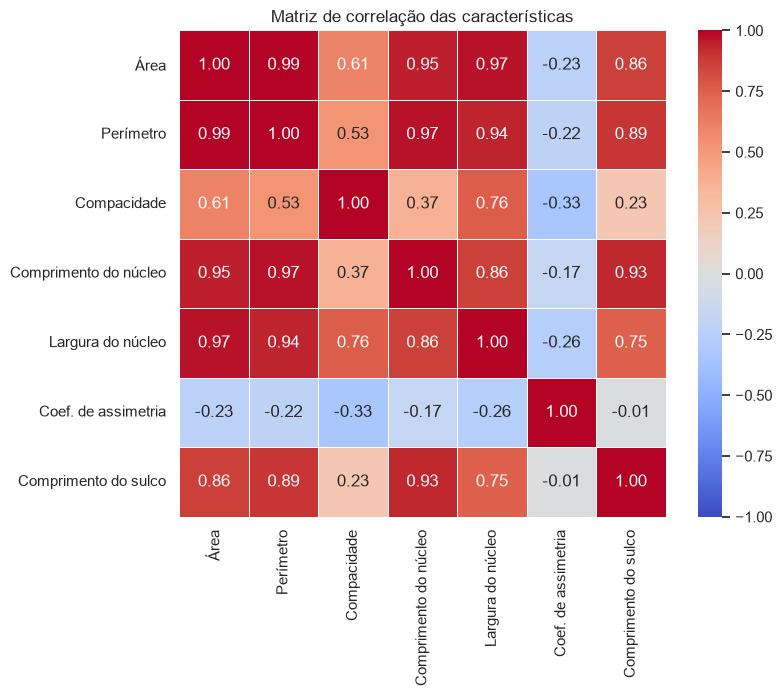

In [10]:
corr = df[FEATURES].corr()
corr.index = FEATURE_LABELS; corr.columns = FEATURE_LABELS
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=ax)
ax.set_title("Matriz de correlação das características")
fig.tight_layout(); save_fig("correlation.png"); plt.show()

**Multicolinearidade acentuada:** `área`, `perímetro`, `comprimento do núcleo`,
`largura do núcleo` e `comprimento do sulco` são quase colineares (correlações
> 0,9). Isso é **inofensivo** para ensembles de árvores (Random Forest) e para o SVM
de margem; para o **KNN**, que é baseado em distância, atributos de "tamanho"
redundantes acabam **implicitamente sobre-ponderando** essa dimensão — algo aceitável
aqui, dada a forte separabilidade, mas não um efeito nulo em geral. De qualquer modo,
a colinearidade explica por que **poucos atributos já bastam** para separar as classes.
O `coeficiente de assimetria` é o atributo mais "independente" dos demais.

### 2.7 Relações entre características — dispersão (scatter matrix)

A matriz de dispersão (colorida por variedade) é a melhor forma de enxergar a
separabilidade: se as cores formam nuvens distintas, um classificador terá vida fácil.

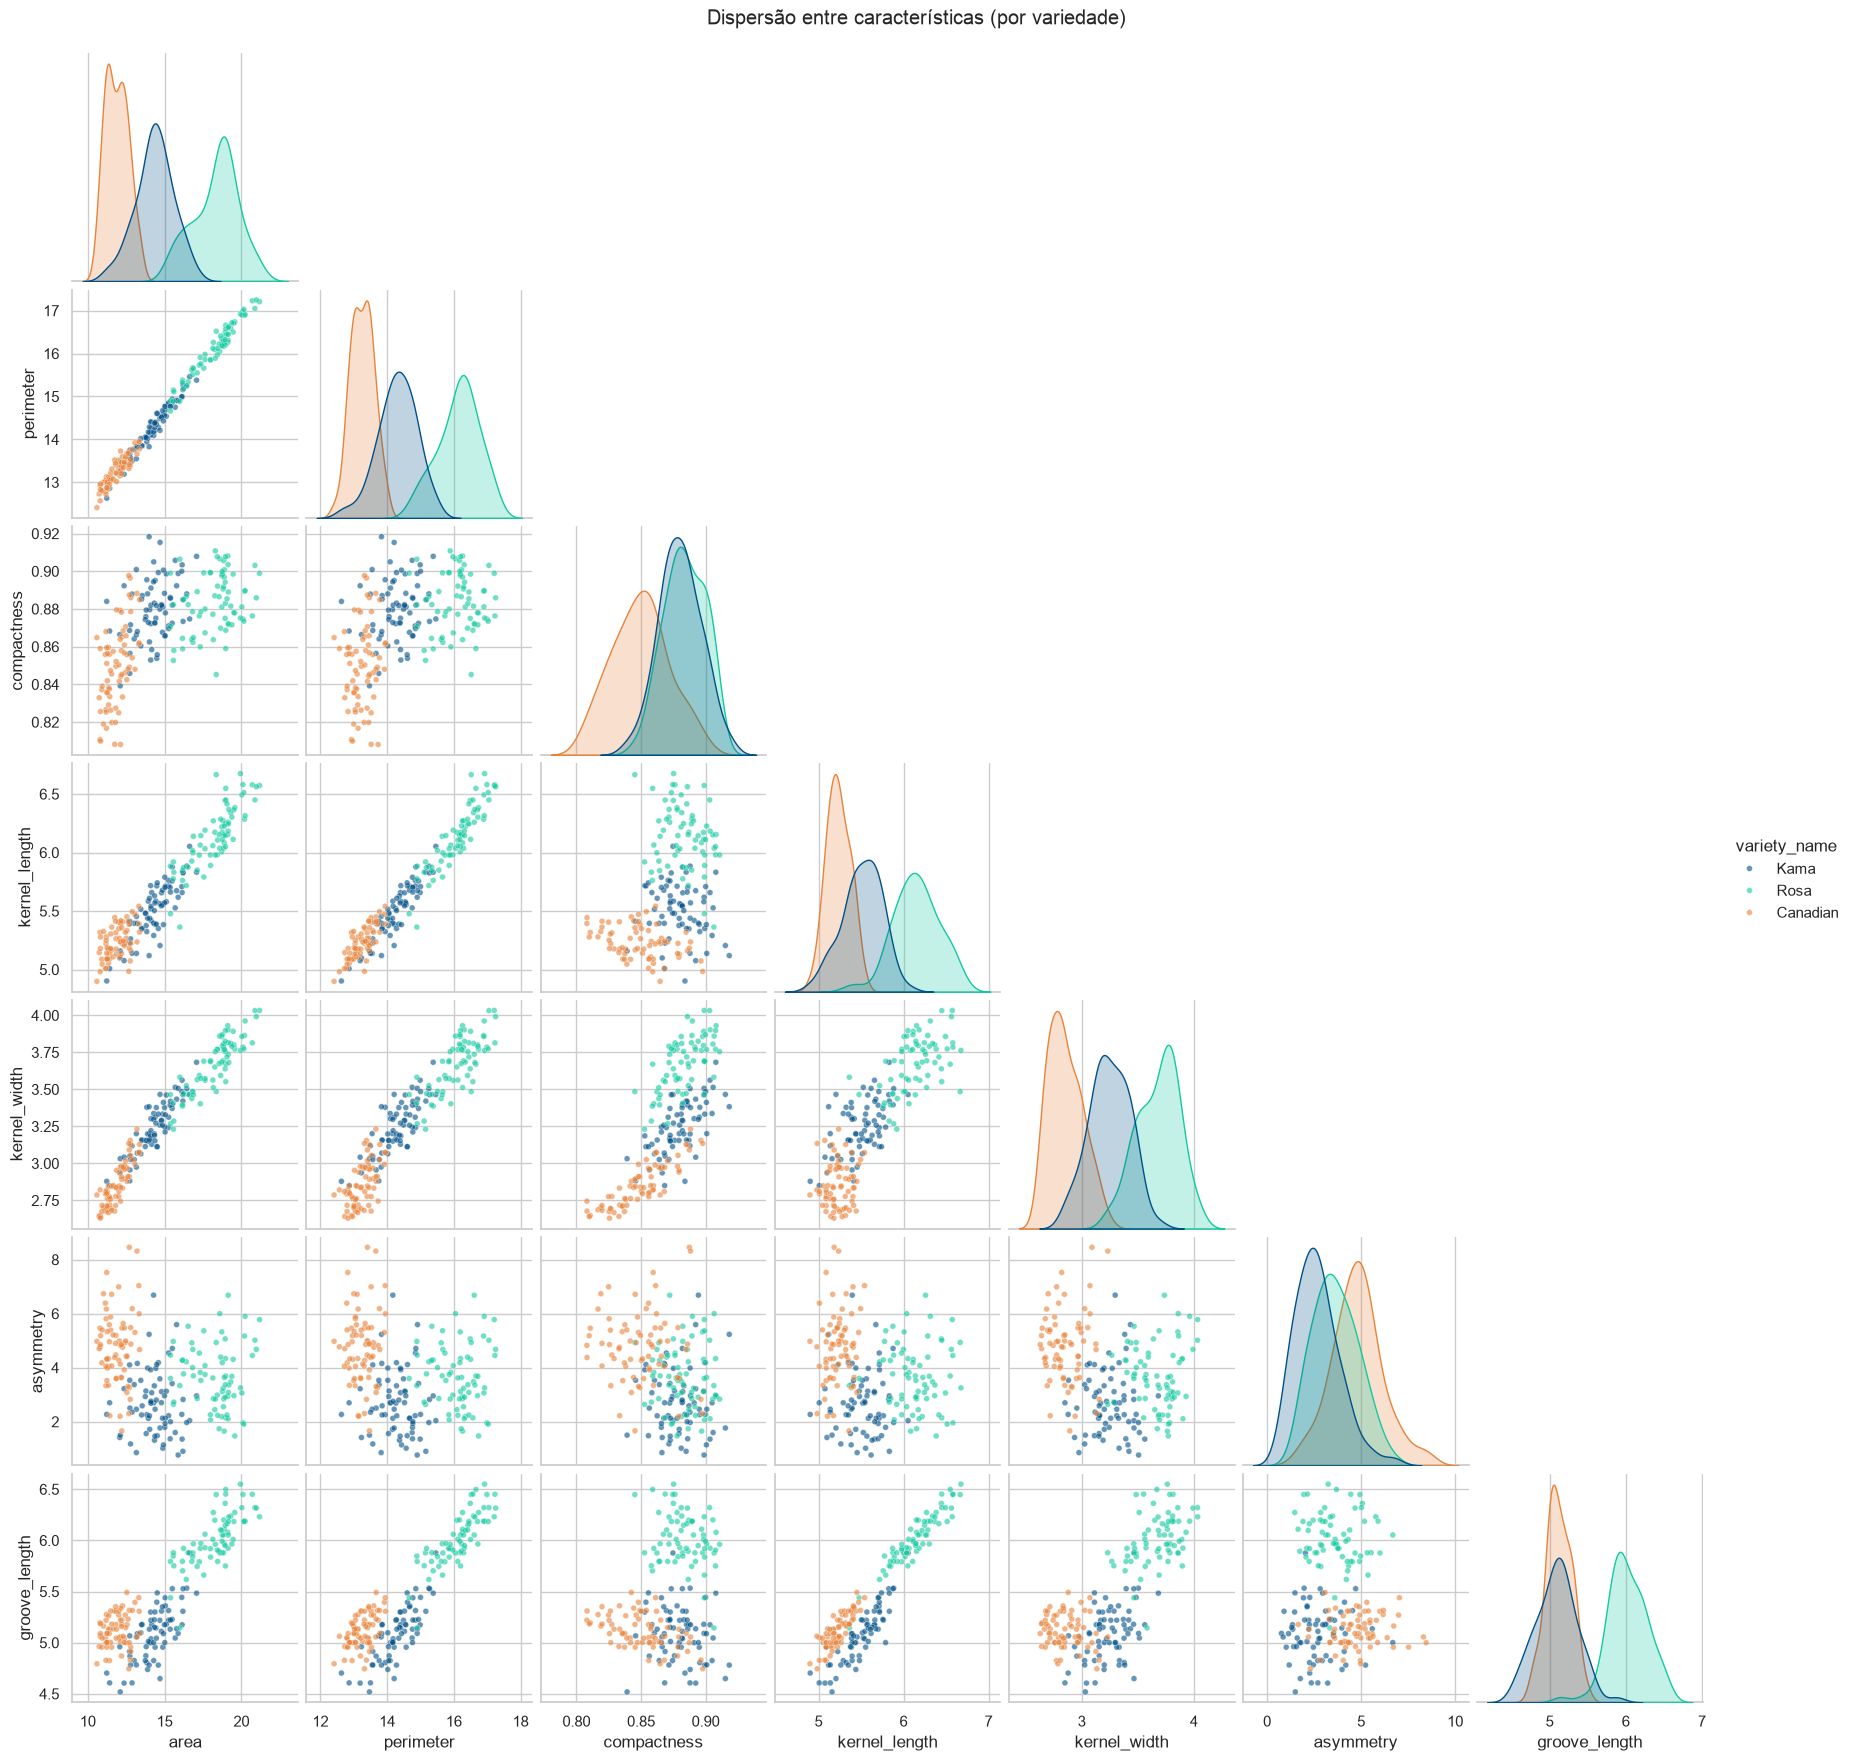

In [11]:
g = sns.pairplot(df, vars=FEATURES, hue=TARGET_NAME, palette=NAME_PALETTE,
                 corner=True, diag_kind="kde", plot_kws=dict(s=18, alpha=0.6))
g.figure.suptitle("Dispersão entre características (por variedade)", y=1.01)
g.savefig(FIGURES_DIR / "pairplot.png", dpi=110, bbox_inches="tight")
plt.show()

A **Rosa** (verde) se destaca como o maior grão na maioria dos pares de atributos.
A **Kama** (azul), de tamanho **intermediário**, encosta tanto na **Canadian**
(laranja, menor) quanto na própria Rosa — é nessa dupla fronteira que os erros de
classificação vão se concentrar.

## 3. Preparação dos Dados (Data Preparation)

### 3.1 Valores ausentes
Já confirmado na seção 2.3: **não há valores ausentes**, portanto nenhuma imputação
é necessária.

### 3.2 Necessidade de escalonamento
As características estão em **escalas muito diferentes** (a área varia ~10–21,
enquanto a compacidade varia ~0,81–0,92). Modelos baseados em **distância** (KNN),
**margem** (SVM) e **regularização** (Regressão Logística) são sensíveis a escala e
exigem **padronização** (`StandardScaler`). Random Forest e Naive Bayes são
invariantes à escala, mas padronizar não os prejudica.

> **Decisão (sem vazamento de dados):** o `StandardScaler` é encapsulado em um
> `Pipeline` junto de cada modelo. Assim o *scaler* é ajustado **apenas com os
> dados de treino de cada *fold*** da validação cruzada e do *Grid Search* — nunca
> com os dados de teste. Isso evita o vazamento clássico de padronizar antes do split.

In [12]:
# Feature scale disparity — motivation for standardization.
df[FEATURES].agg(["min", "max", "mean", "std"]).T.rename(
    index=FEATURE_LABELS_PT,
    columns={"min": "Mínimo", "max": "Máximo", "mean": "Média", "std": "Desvio"},
).round(3)

,Mínimo,Máximo,Média,Desvio
Área,10.590,21.180,14.848,2.910
Perímetro,12.410,17.250,14.559,1.306
Compacidade,0.808,0.918,0.871,0.024
Comprimento do núcleo,4.899,6.675,5.629,0.443
Largura do núcleo,2.630,4.033,3.259,0.378
Coef. de assimetria,0.765,8.456,3.700,1.504
Comprimento do sulco,4.519,6.550,5.408,0.491


### 3.3 Separação treino/teste (70% / 30%, estratificada)

Usamos `stratify=y` para preservar a proporção 1/3 de cada variedade em ambos os
conjuntos, e `random_state=SEED` para reprodutibilidade.

In [13]:
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

balance = pd.DataFrame({
    "Treino": y_train.map(CLASS_MAP).value_counts().reindex(CLASS_NAMES),
    "Teste": y_test.map(CLASS_MAP).value_counts().reindex(CLASS_NAMES),
})
balance

Treino: 147 amostras | Teste: 63 amostras


,Treino,Teste
variety,,
Kama,49,21
Rosa,49,21
Canadian,49,21


> ⚠️ **Observação importante para a interpretação:** o conjunto de teste tem apenas
> **63 amostras** (21 por classe). Cada amostra vale ~1,6 ponto percentual de
> acurácia, então a métrica numa única partição é **ruidosa**. Por isso usamos
> **validação cruzada (5 folds)** sobre o treino como critério principal de
> comparação e seleção — ela é muito mais estável.

## 4. Modelagem (Modeling)

Treinamos **cinco** algoritmos de classificação clássicos, cada um dentro de um
`Pipeline` com `StandardScaler`:

1. **K-Nearest Neighbors (KNN)** — vizinhança no espaço de atributos;
2. **Support Vector Machine (SVM)** — margem máxima (kernel RBF/linear);
3. **Random Forest** — ensemble de árvores de decisão;
4. **Naive Bayes (Gaussiano)** — probabilístico, assume independência condicional;
5. **Regressão Logística** — modelo linear multinomial (baseline).

Para cada um avaliamos: (a) desempenho na **partição de teste** e (b) **F1-macro em
validação cruzada** sobre o treino (estabilidade).

In [14]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
models = build_models()

baseline_rows = []
cv_scores = {}
for name, spec in models.items():
    pipe = spec["pipeline"]
    pipe.fit(X_train, y_train)                       # fit on the training set
    test_metrics = compute_metrics(y_test, pipe.predict(X_test))
    # cross_val_score clones the estimator, so the fit above does not leak in.
    scores = cross_val_score(spec["pipeline"], X_train, y_train, cv=cv, scoring=SCORING)
    cv_scores[name] = scores
    baseline_rows.append({
        "Modelo": name, **test_metrics,
        "CV F1 (média)": scores.mean(), "CV F1 (desvio)": scores.std(),
    })

baseline_df = pd.DataFrame(baseline_rows).set_index("Modelo").round(4)
baseline_df.to_csv(METRICS_BASELINE_PATH)
print("Métricas (modelos com hiperparâmetros padrão) — salvas em", METRICS_BASELINE_PATH.name)
baseline_df

Métricas (modelos com hiperparâmetros padrão) — salvas em metrics_baseline.csv


,Accuracy,Precision,Recall,F1,CV F1 (média),CV F1 (desvio)
Modelo,,,,,,
KNN,0.8730,0.8721,0.8730,0.8713,0.9182,0.0271
SVM,0.8730,0.8721,0.8730,0.8713,0.9388,0.0402
Random Forest,0.9206,0.9239,0.9206,0.9192,0.9031,0.0804
Naive Bayes,0.8254,0.8339,0.8254,0.8251,0.9234,0.0480
Logistic Regression,0.8571,0.8571,0.8571,0.8543,0.9454,0.0415


### 4.1 Estabilidade por validação cruzada

O *boxplot* abaixo mostra a dispersão do F1-macro nos 5 *folds*. Modelos com caixa
alta **e** estreita são preferíveis: bom desempenho **e** baixa variância.

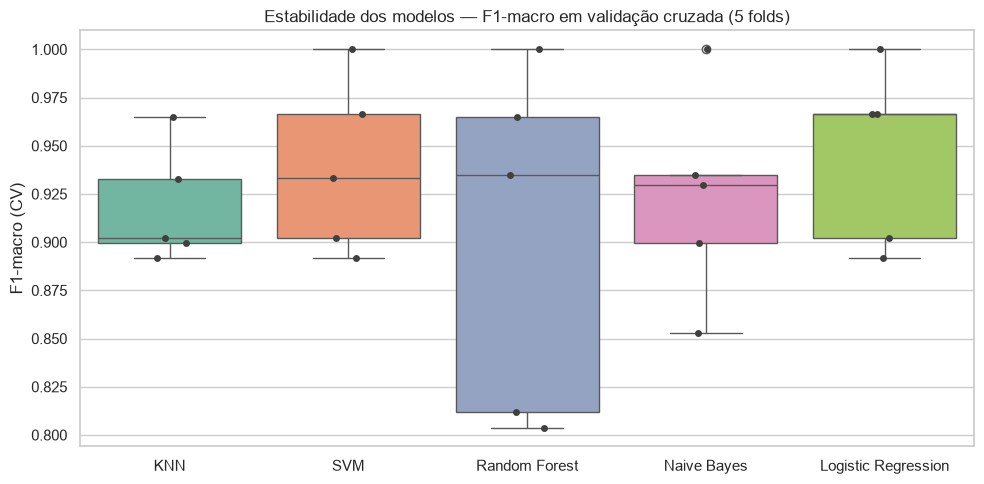

In [15]:
cv_long = pd.DataFrame(cv_scores).melt(var_name="Modelo", value_name="F1-macro (CV)")
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=cv_long, x="Modelo", y="F1-macro (CV)", hue="Modelo",
            palette="Set2", legend=False, ax=ax)
sns.stripplot(data=cv_long, x="Modelo", y="F1-macro (CV)", color=".25", size=5, ax=ax)
ax.set_title("Estabilidade dos modelos — F1-macro em validação cruzada (5 folds)")
ax.set_xlabel("")
fig.tight_layout(); save_fig("cv_stability.png"); plt.show()

## 5. Avaliação (Evaluation) — matrizes de confusão

As matrizes de confusão revelam **onde** cada modelo erra. Mais importante que a
acurácia global é saber **quais variedades são confundidas**.

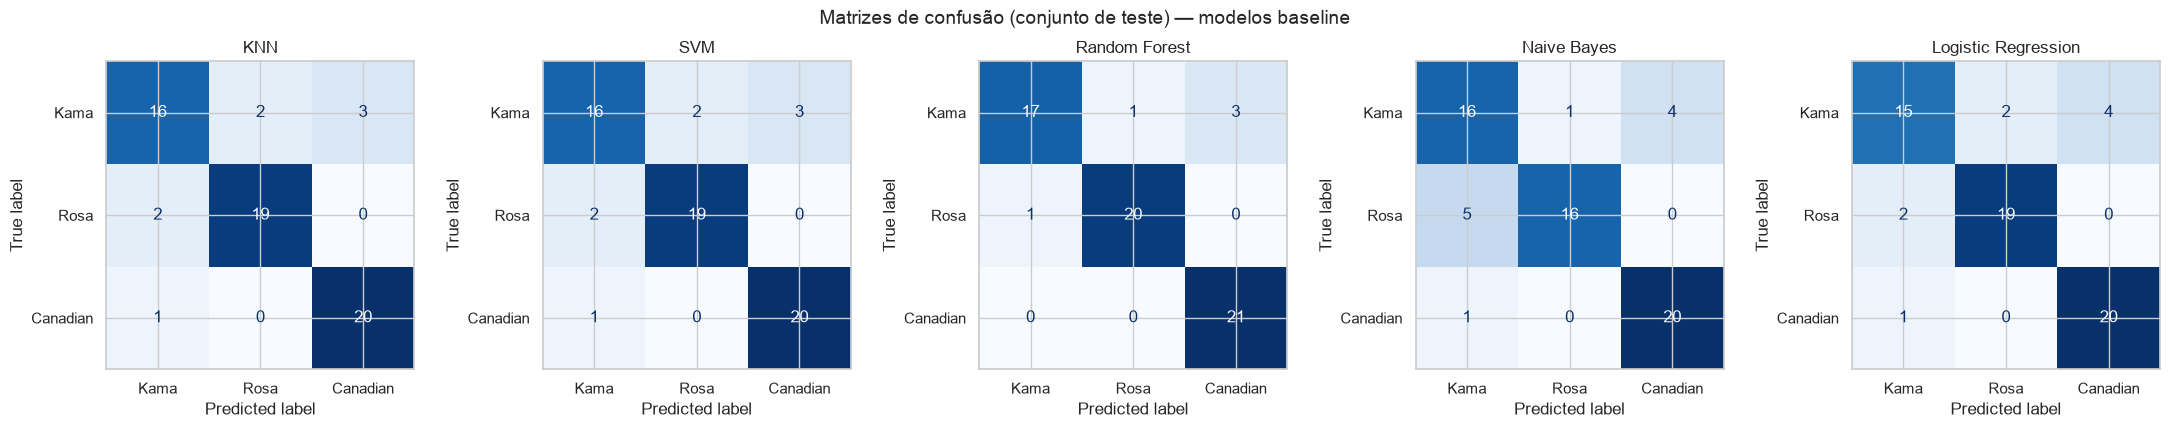

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (name, spec) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, spec["pipeline"].predict(X_test),
        labels=CLASS_LABELS, display_labels=CLASS_NAMES,
        cmap="Blues", colorbar=False, ax=ax,
    )
    ax.set_title(name)
fig.suptitle("Matrizes de confusão (conjunto de teste) — modelos baseline", fontsize=14)
fig.tight_layout(); save_fig("confusion_baseline.png"); plt.show()

Em todos os modelos o padrão se repete: os erros **envolvem quase sempre a Kama** —
a variedade intermediária —, confundida ora com a Rosa, ora com a Canadian.
**Rosa e Canadian praticamente nunca são confundidas entre si** (zero erros mútuos
em todos os modelos), exatamente como a matriz de dispersão (seção 2.7) antecipou.

## 6. Otimização de Hiperparâmetros (Grid Search)

Usamos **`GridSearchCV`** com a mesma validação cruzada estratificada (5 folds),
otimizando o **F1-macro**. Os espaços de busca de cada modelo estão centralizados em
`config.build_models()`. Como o *scaler* faz parte do `Pipeline`, a padronização é
re-ajustada dentro de cada *fold* da busca — **sem vazamento**.

In [17]:
tuned_rows = []
best_estimators = {}
best_params = {}
for name, spec in models.items():
    gs = GridSearchCV(spec["pipeline"], spec["grid"], cv=cv,
                      scoring=SCORING, n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_
    best_params[name] = gs.best_params_
    test_metrics = compute_metrics(y_test, gs.predict(X_test))
    tuned_rows.append({"Modelo": name, **test_metrics, "CV F1 (melhor)": gs.best_score_})

tuned_df = pd.DataFrame(tuned_rows).set_index("Modelo").round(4)
tuned_df.to_csv(METRICS_TUNED_PATH)
with open(BEST_PARAMS_PATH, "w") as f:
    json.dump(best_params, f, indent=2)
print("Métricas otimizadas salvas em", METRICS_TUNED_PATH.name,
      "| hiperparâmetros em", BEST_PARAMS_PATH.name)
tuned_df

Métricas otimizadas salvas em metrics_tuned.csv | hiperparâmetros em best_params.json


,Accuracy,Precision,Recall,F1,CV F1 (melhor)
Modelo,,,,,
KNN,0.8889,0.8880,0.8889,0.8881,0.9461
SVM,0.8571,0.8555,0.8571,0.8540,0.9593
Random Forest,0.9048,0.9112,0.9048,0.9025,0.9096
Naive Bayes,0.8254,0.8339,0.8254,0.8251,0.9234
Logistic Regression,0.8889,0.8899,0.8889,0.8884,0.9514


In [18]:
# Best hyperparameters found per model.
print("Melhores hiperparâmetros (Grid Search):\n")
for name, params in best_params.items():
    pretty = {k.replace("clf__", ""): v for k, v in params.items()}
    print(f"  {name:20s} {pretty}")

Melhores hiperparâmetros (Grid Search):

  KNN                  {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
  SVM                  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Random Forest        {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
  Naive Bayes          {'var_smoothing': 1e-09}
  Logistic Regression  {'C': 10}


### 6.1 Matrizes de confusão dos modelos otimizados

Para fechar a avaliação de forma simétrica ao baseline (seção 5), mostramos as
matrizes de confusão dos **cinco modelos otimizados** no conjunto de teste.

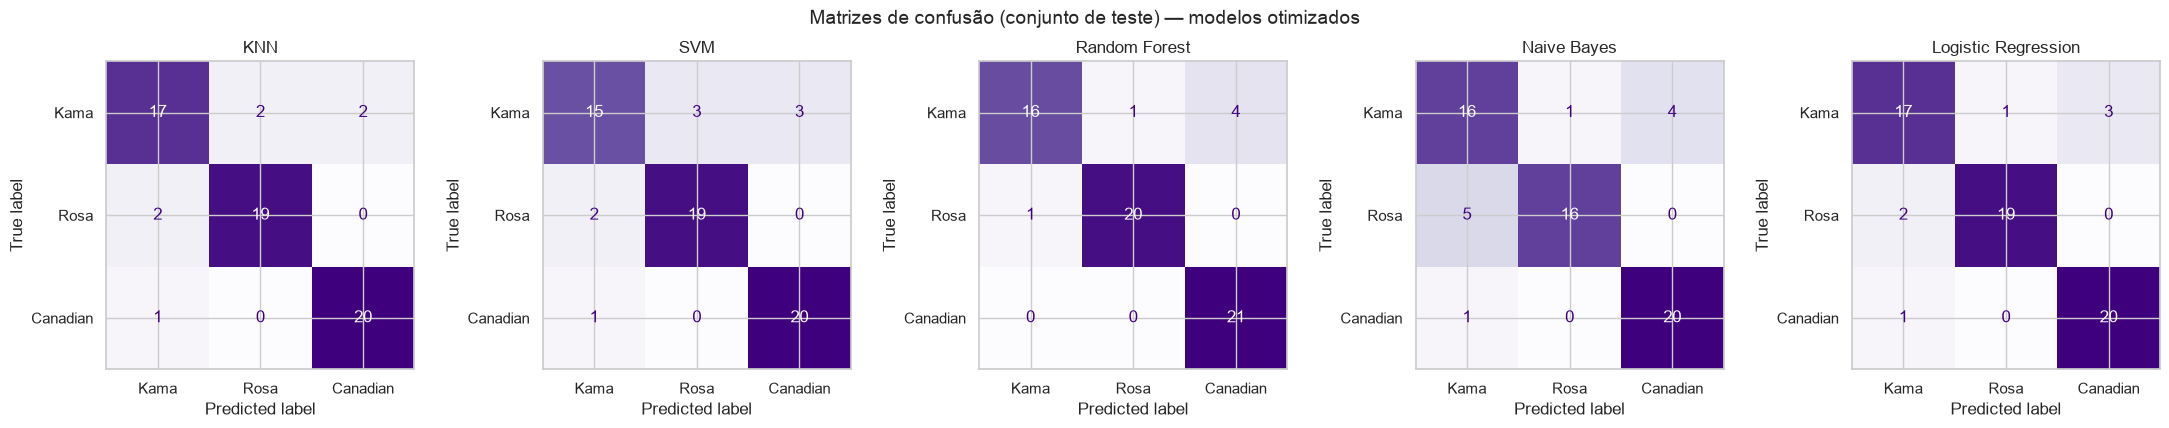

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (name, est) in zip(axes, best_estimators.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, est.predict(X_test),
        labels=CLASS_LABELS, display_labels=CLASS_NAMES,
        cmap="Purples", colorbar=False, ax=ax,
    )
    ax.set_title(name)
fig.suptitle("Matrizes de confusão (conjunto de teste) — modelos otimizados", fontsize=14)
fig.tight_layout(); save_fig("confusion_tuned.png"); plt.show()

### 6.2 Comparação: baseline × otimizado

In [20]:
compare = pd.DataFrame({
    "F1 teste (baseline)": baseline_df["F1"],
    "F1 teste (otimizado)": tuned_df["F1"],
    "F1 CV (baseline)": baseline_df["CV F1 (média)"],
    "F1 CV (otimizado)": tuned_df["CV F1 (melhor)"],
}).round(4)
compare["Δ F1 CV"] = (compare["F1 CV (otimizado)"] - compare["F1 CV (baseline)"]).round(4)
compare

,F1 teste (baseline),F1 teste (otimizado),F1 CV (baseline),F1 CV (otimizado),Δ F1 CV
Modelo,,,,,
KNN,0.8713,0.8881,0.9182,0.9461,0.0279
SVM,0.8713,0.8540,0.9388,0.9593,0.0205
Random Forest,0.9192,0.9025,0.9031,0.9096,0.0065
Naive Bayes,0.8251,0.8251,0.9234,0.9234,0.0000
Logistic Regression,0.8543,0.8884,0.9454,0.9514,0.0060


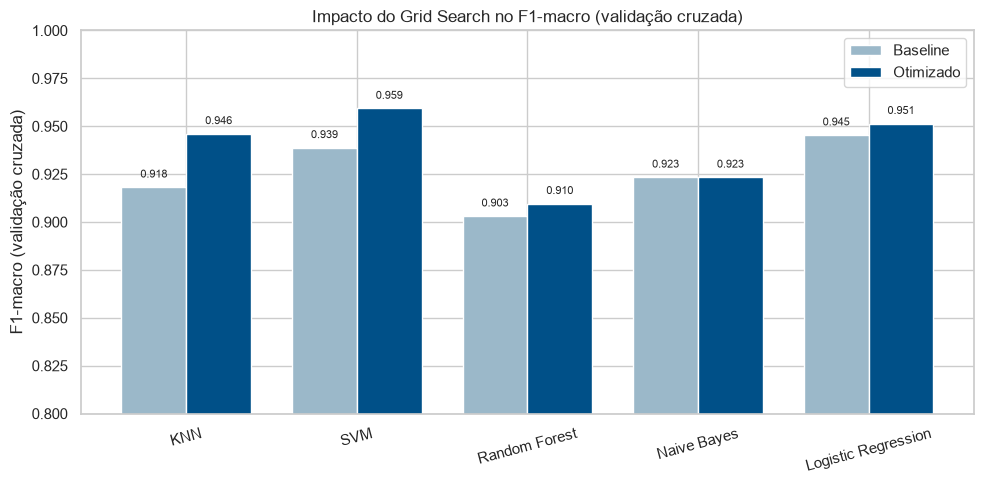

In [21]:
# Visual comparison of the cross-validated F1 (the reliable metric).
fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(compare)); w = 0.38
ax.bar(idx - w/2, compare["F1 CV (baseline)"], width=w, label="Baseline", color="#9bb8c9")
ax.bar(idx + w/2, compare["F1 CV (otimizado)"], width=w, label="Otimizado", color="#005088")
ax.set_xticks(idx); ax.set_xticklabels(compare.index, rotation=15)
ax.set_ylim(0.80, 1.0); ax.set_ylabel("F1-macro (validação cruzada)")
ax.set_title("Impacto do Grid Search no F1-macro (validação cruzada)")
ax.legend()
for i, (b, t) in enumerate(zip(compare["F1 CV (baseline)"], compare["F1 CV (otimizado)"])):
    ax.text(i - w/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=8)
fig.tight_layout(); save_fig("comparison.png"); plt.show()

**Leitura honesta dos resultados:** o ganho do *Grid Search* é **modesto** — o
dataset é simples e os modelos já chegam perto do teto com configurações padrão.
Três ressalvas para não superestimar o ganho:

- As colunas não são totalmente comparáveis: `F1 CV (baseline)` é a **média** dos
  *folds* de **uma única** configuração padrão, enquanto `F1 CV (otimizado)` é o
  `best_score_` — o **máximo** sobre toda a grade nos mesmos *folds*. Esse máximo é
  **enviesado para cima** (*winner's curse* da seleção), então o `Δ F1 CV` é uma
  estimativa **otimista** do benefício real do ajuste.
- O **Naive Bayes** tem ganho **zero por construção**: o melhor `var_smoothing`
  encontrado (1e-09) é justamente o **padrão** do `GaussianNB`.
- A acurácia na partição de teste pode até **cair** após a otimização — esperado,
  pois o *Grid Search* otimiza o F1 **em validação cruzada**, e o teste de 63
  amostras é ruidoso demais para ser o juiz final.

### 6.3 Seleção do modelo final

Escolhemos o modelo final pelo **maior F1-macro em validação cruzada** (critério
estável), e só então reportamos seu desempenho no conjunto de teste — que funciona
como uma estimativa **imparcial** de generalização.

> Note que a **Random Forest** lidera na **acurácia de teste** (tabelas anteriores),
> mas selecionamos por **F1-macro de validação cruzada** por ser mais robusto ao
> ruído da partição única de 63 amostras — e, por esse critério, o **SVM** vence.
> Não há contradição: são dois recortes diferentes do mesmo resultado.

In [22]:
final_name = tuned_df["CV F1 (melhor)"].idxmax()
final_model = best_estimators[final_name]
final_pred = final_model.predict(X_test)
final_params = {k.replace("clf__", ""): v for k, v in best_params[final_name].items()}

print(f"Modelo final selecionado: {final_name}")
print(f"Hiperparâmetros: {final_params}")
print(f"F1-macro (validação cruzada): {tuned_df.loc[final_name, 'CV F1 (melhor)']:.4f}\n")
print("Relatório de classificação no conjunto de teste:\n")
print(classification_report(y_test, final_pred, labels=CLASS_LABELS,
                            target_names=CLASS_NAMES, digits=3))

Modelo final selecionado: SVM
Hiperparâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
F1-macro (validação cruzada): 0.9593

Relatório de classificação no conjunto de teste:

              precision    recall  f1-score   support

        Kama      0.833     0.714     0.769        21
        Rosa      0.864     0.905     0.884        21
    Canadian      0.870     0.952     0.909        21

    accuracy                          0.857        63
   macro avg      0.856     0.857     0.854        63
weighted avg      0.856     0.857     0.854        63



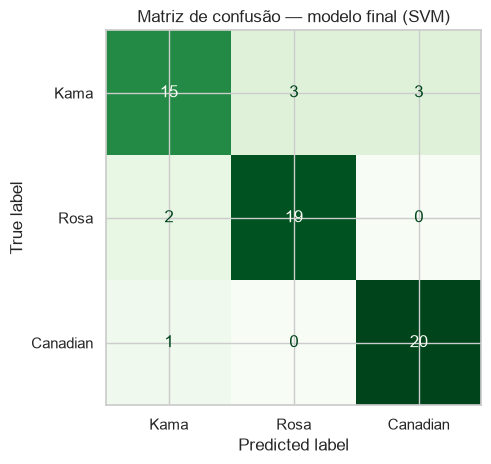

Modelo final serializado em model_best.pkl


In [23]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_test, final_pred, labels=CLASS_LABELS, display_labels=CLASS_NAMES,
    cmap="Greens", colorbar=False, ax=ax,
)
ax.set_title(f"Matriz de confusão — modelo final ({final_name})")
fig.tight_layout(); save_fig("confusion_final.png"); plt.show()

# Persist the final model + metadata for reuse (e.g. a future API/dashboard).
joblib.dump(
    {"model": final_model, "name": final_name, "features": FEATURES,
     "params": best_params[final_name], "classes": CLASS_MAP},
    MODELS_DIR / "model_best.pkl",
)
print("Modelo final serializado em", (MODELS_DIR / "model_best.pkl").name)

## 7. Interpretação e Insights

### 7.1 Quais atributos mais discriminam as variedades?

Combinamos duas visões de importância:
- **Random Forest** — importância nativa (redução de impureza), específica do ensemble;
- **Importância por permutação** — métrica **agnóstica ao modelo**, medida sobre o
  modelo final embaralhando cada atributo no conjunto de teste e observando a queda no F1.

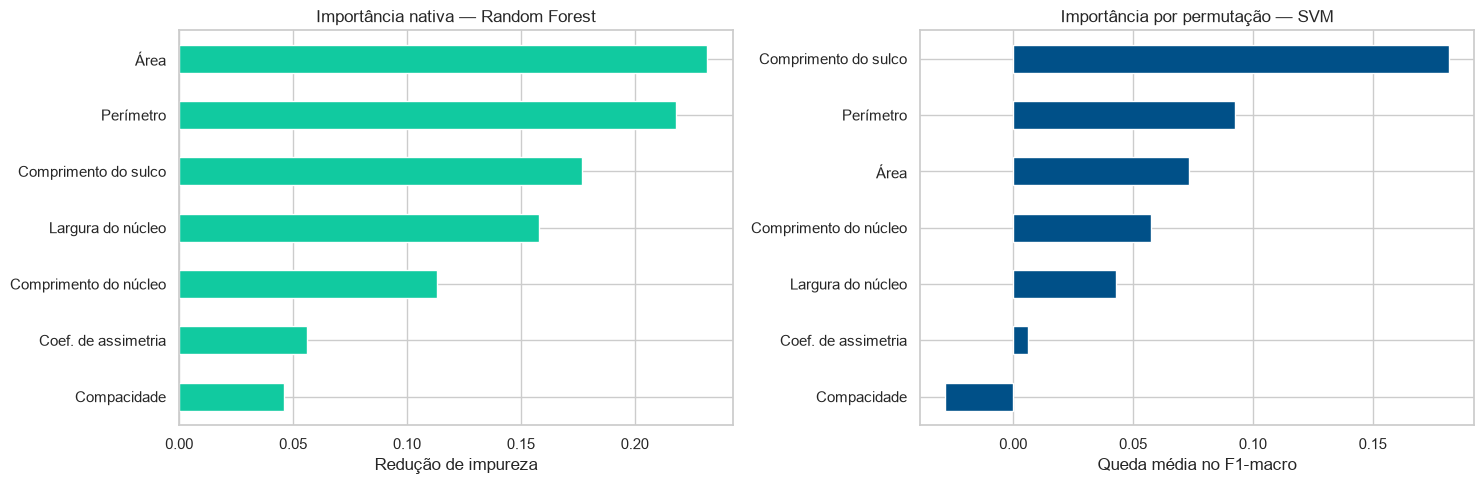

In [24]:
rf_pipe = best_estimators["Random Forest"]
rf_importance = pd.Series(
    rf_pipe.named_steps["clf"].feature_importances_, index=FEATURE_LABELS
).sort_values()

perm = permutation_importance(
    final_model, X_test, y_test, n_repeats=30, random_state=SEED, scoring=SCORING
)
perm_importance = pd.Series(perm.importances_mean, index=FEATURE_LABELS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
rf_importance.plot.barh(ax=axes[0], color="#11CAA0")
axes[0].set_title("Importância nativa — Random Forest")
axes[0].set_xlabel("Redução de impureza")
perm_importance.plot.barh(ax=axes[1], color="#005088")
axes[1].set_title(f"Importância por permutação — {final_name}")
axes[1].set_xlabel("Queda média no F1-macro")
fig.tight_layout(); save_fig("feature_importance.png"); plt.show()

As duas abordagens concordam: **comprimento do sulco**, **área** e **perímetro** são
os atributos mais informativos para separar as variedades — coerente com o fato de a
**Rosa** ser claramente a maior das três. O **coeficiente de assimetria** contribui
pouco, como já sugeriam os boxplots.

### 7.2 Visualização da separabilidade — PCA (2 componentes)

Projetar os dados padronizados em 2 componentes principais permite "enxergar" em um
plano por que o problema é tão separável (visualização exploratória; o PCA **não**
faz parte do modelo final).

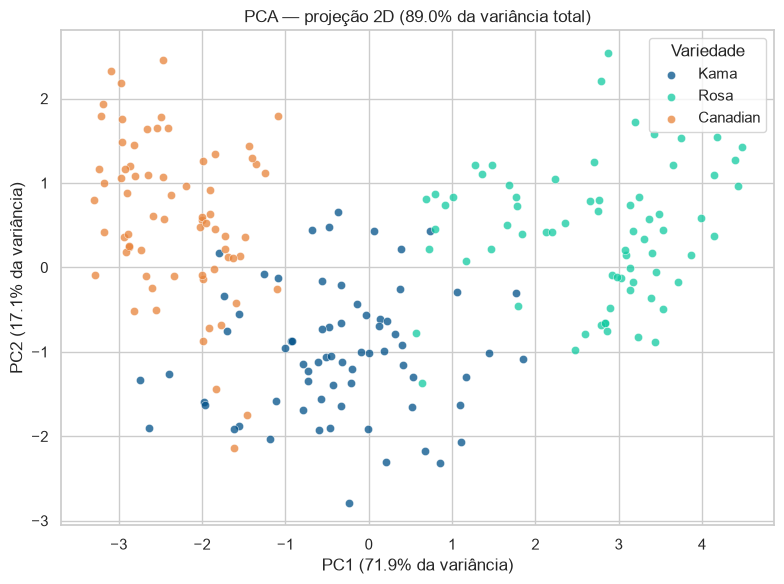

In [25]:
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=SEED).fit(X_std)
proj = pca.transform(X_std)
ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
for cls, name in CLASS_MAP.items():
    mask = (y.values == cls)
    ax.scatter(proj[mask, 0], proj[mask, 1], label=name, color=PALETTE[cls],
               s=35, alpha=0.75, edgecolors="white", linewidths=0.4)
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% da variância)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% da variância)")
ax.set_title(f"PCA — projeção 2D ({ev.sum()*100:.1f}% da variância total)")
ax.legend(title="Variedade")
fig.tight_layout(); save_fig("pca_2d.png"); plt.show()

As duas primeiras componentes retêm **~89%** da variância e revelam **três
agrupamentos** ordenados pelo tamanho do grão: **Canadian** (menor) à esquerda,
**Rosa** (maior) à direita e **Kama** no centro, encostando em ambas. Essa posição
intermediária da Kama é a origem geométrica dos poucos erros do classificador —
todos eles envolvendo justamente essa variedade.

### 7.3 Mais dados ajudariam? — curva de aprendizado

A curva é calculada por validação cruzada **apenas sobre o conjunto de treino**
(o teste permanece intocado): ela mostra como o desempenho evolui conforme mais
grãos são usados no treino — útil para a cooperativa decidir se vale a pena coletar
mais amostras.

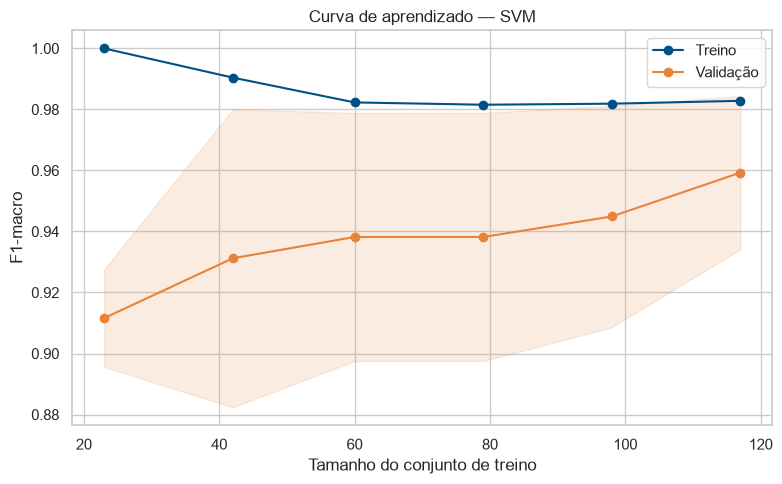

In [26]:
# Computed on the TRAINING set only (the held-out test set stays untouched),
# consistent with the rest of the notebook's train/test discipline.
sizes, train_sc, val_sc = learning_curve(
    final_model, X_train, y_train, cv=cv, scoring=SCORING,
    train_sizes=np.linspace(0.2, 1.0, 6), shuffle=True, random_state=SEED,
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, train_sc.mean(axis=1), "o-", color="#005088", label="Treino")
ax.plot(sizes, val_sc.mean(axis=1), "o-", color="#E8833A", label="Validação")
ax.fill_between(sizes, val_sc.mean(axis=1) - val_sc.std(axis=1),
                val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.15, color="#E8833A")
ax.set_xlabel("Tamanho do conjunto de treino")
ax.set_ylabel("F1-macro")
ax.set_title(f"Curva de aprendizado — {final_name}")
ax.legend()
fig.tight_layout(); save_fig("learning_curve.png"); plt.show()

## 8. Conclusões e Recomendações para a Cooperativa

**Resultado.** É perfeitamente viável **automatizar a classificação das variedades de
trigo** com aprendizado de máquina: os cinco algoritmos atingem **F1-macro em torno
de 0,90–0,96** em validação cruzada, e o modelo final generaliza bem para grãos não
vistos. A classificação manual pode ser substituída (ou assistida) por um modelo que
decide em milissegundos.

**Onde estão os erros.** Praticamente todos **envolvem a Kama**, a variedade de
tamanho intermediário, confundida ora com a Rosa, ora com a Canadian. **Rosa e
Canadian quase nunca são confundidas entre si** — são as variedades extremas em
tamanho e, portanto, geometricamente bem separadas.

**O que medir com prioridade.** **Comprimento do sulco**, **área** e **perímetro**
são os atributos mais discriminantes. Se a cooperativa precisar reduzir custo de
medição, esses três são os que mais preservam a acurácia; o **coeficiente de
assimetria** é o menos relevante.

**Recomendações práticas:**
1. **Adotar o modelo otimizado** como triagem automática, mantendo a inspeção humana
   apenas nos casos de **baixa confiança** (tipicamente grãos na fronteira Kama/Canadian).
2. **Padronizar a captura das medidas** (mesma calibração de imagem), já que o modelo
   depende da escala dos atributos físicos.
3. **Ampliar a base de Kama e Canadian** para reforçar justamente a fronteira mais
   difícil — a curva de aprendizado indica se há ganho marginal com mais dados.
4. **Reavaliar o modelo periodicamente** (novas safras/variedades), reusando este
   mesmo pipeline reprodutível (`make pipeline`).

> **Reprodutibilidade:** todo o processo é determinístico (`random_state=42`). As
> métricas, os hiperparâmetros e o modelo final ficam salvos em `src/models/`, e as
> figuras em `docs/figures/`.